In [1]:
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
import numpy as np

/jet/home/hsun3/.local/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/jet/home/hsun3/.local/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [32]:
# -----------------------------------------
# Fixed parameters
# -----------------------------------------
seasons = ["DJF", "MAM", "JJA", "SON"]

In [33]:
# -----------------------------------------
# Function to read a 4-season dataset
# -----------------------------------------
# def read_seasonal_dataset(files, value_col="z_mean"):
#     seasonal_data = {}
#     for season, f in zip(seasons, files):
#         df = pd.read_csv(f, sep="\s+")
#         da = df.pivot(index="lat", columns="lon", values=value_col)
#         seasonal_data[season] = xr.DataArray(da.values,
#                                              coords={"lat":da.index,"lon":da.columns},
#                                              dims=["lat","lon"])
#     return seasonal_data


def read_seasonal_dataset(files, value_col="z_mean"):
    seasonal_data = {}
    
    # Read each season
    for season, f in zip(seasons, files):
        df = pd.read_csv(f, sep="\s+")
        da = df.pivot(index="lat", columns="lon", values=value_col)
        
        # Convert to xarray DataArray
        seasonal_data[season] = xr.DataArray(
            da.values,
            coords={"lat": da.index, "lon": da.columns},
            dims=["lat", "lon"]
        )
    
    # --- calculate annual mean ---
    # Stack the 4 seasons along a new 'season' axis
    stacked = xr.concat([seasonal_data[s] for s in seasons], dim="season")
    
    # Mean along the 'season' axis
    seasonal_data["ANN"] = stacked.mean(dim="season")
    
    return seasonal_data

In [34]:
# # -----------------------------------------
# # Load WMO 1st dataset
# # -----------------------------------------
# dataset = "era5_wmo_1st" # "era5_dyn" # 
# files = [f"./Seasonal_Data/{dataset}_{s}.tab" for s in seasons]
# seasonal_data = read_seasonal_dataset(files)

# -----------------------------------------
# Load WMO and Dynamic tropopause datasets
# -----------------------------------------
dataset1 = "era5_wmo_1st"
dataset2 = "era5_dyn"

files1 = [f"./Seasonal_Data/{dataset1}_{s}.tab" for s in seasons]
files2 = [f"./Seasonal_Data/{dataset2}_{s}.tab" for s in seasons]

seasonal_wmo = read_seasonal_dataset(files1)
seasonal_dyn = read_seasonal_dataset(files2)

In [36]:
seasons_ann = seasons+ ["ANN"]
seasons_ann

['DJF', 'MAM', 'JJA', 'SON', 'ANN']

In [37]:
# -----------------------------------------
# Use the lower tropopause height
# -----------------------------------------
seasonal_data = {}

for season in seasons_ann:
    
    da_wmo = seasonal_wmo[season]
    da_dyn = seasonal_dyn[season]
    
    # take minimum height at each grid point
    seasonal_data[season] = np.minimum(da_wmo, da_dyn)
#     seasonal_data[season] = da_wmo


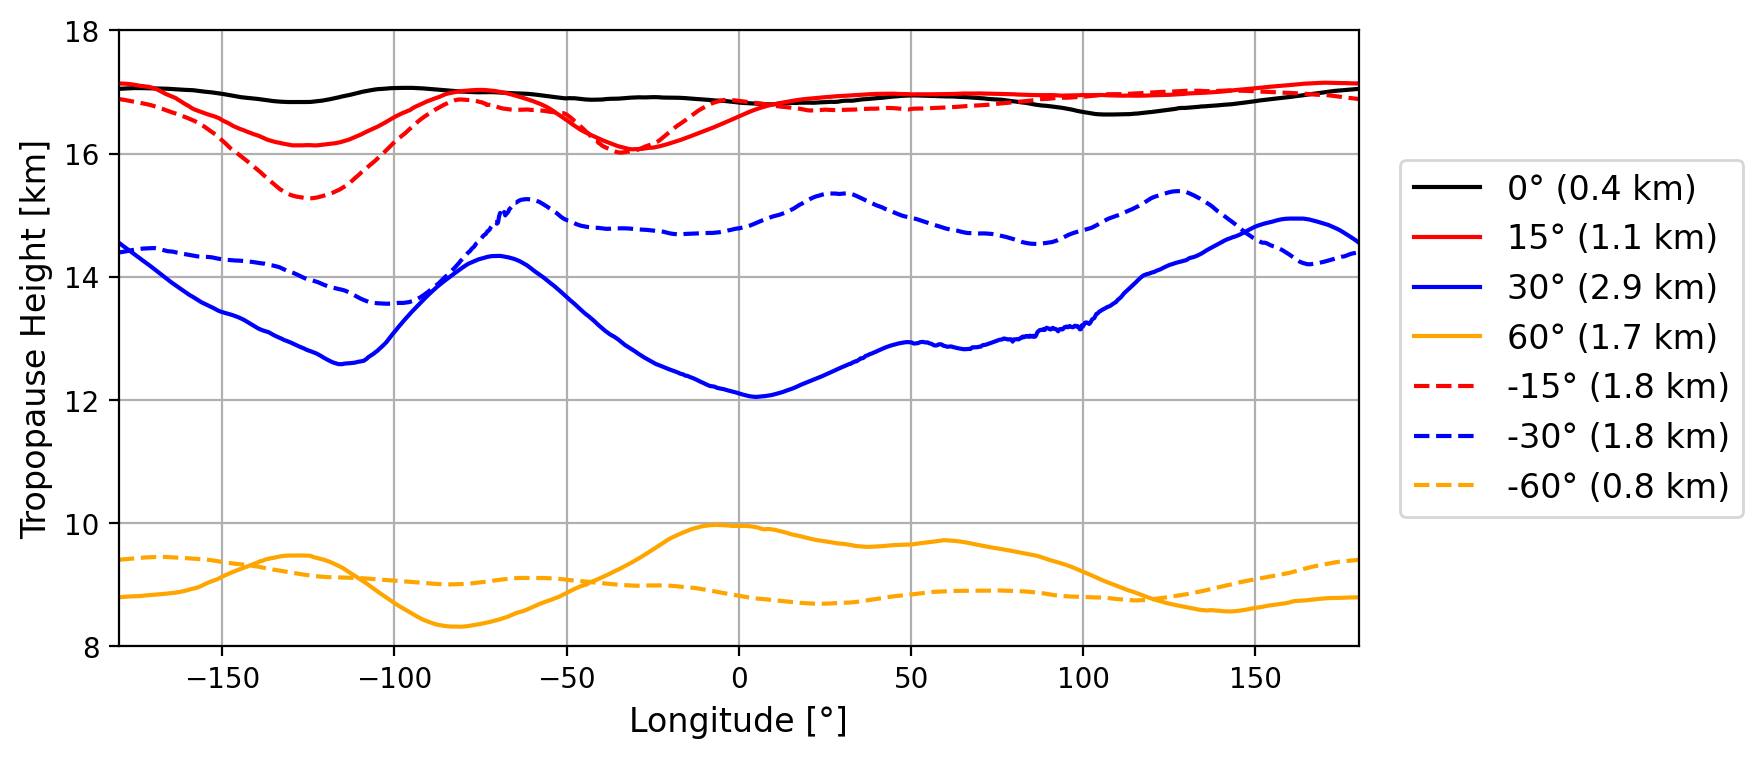

In [64]:

season = "DJF"   # choose which season to plot
da = seasonal_data[season]

plt.figure(figsize=(8,4), dpi=200)

# Define latitude ranges
lat_ranges1 = [(-2,2), (13,17), (28,32), (58,62)]
color = ["black", "red", "blue", "orange"]

i=0
for lat1, lat2 in lat_ranges1:
    
    # Select latitude band
    da_band = da.sel(lat=slice(lat1, lat2))
    
    # Average over latitude
    zonal_profile = da_band.mean(dim="lat")
    
    max_diff = float(zonal_profile.max() - zonal_profile.min())
    
    # Plot
    plt.plot(zonal_profile.lon, zonal_profile, color=color[i],
             label=f"{int((lat1+lat2)/2)}° ({max_diff:.1f} km)")
    
    i = i+1
    
# Define latitude ranges
lat_ranges2 = [(-17,-13), (-32,-28), (-62,-58)]

i=1
for lat1, lat2 in lat_ranges2:
    
    # Select latitude band
    da_band = da.sel(lat=slice(lat1, lat2))
    
    # Average over latitude
    zonal_profile = da_band.mean(dim="lat")
    
    max_diff = float(zonal_profile.max() - zonal_profile.min())
    
    # Plot
    plt.plot(zonal_profile.lon, zonal_profile, '--', color=color[i],
             label=f"{int((lat1+lat2)/2)}° ({max_diff:.1f} km)")

    i = i+1

plt.ylim(8,18)
plt.xlim(-180,180)
    
plt.xlabel("Longitude [°]", fontsize=12)
plt.ylabel("Tropopause Height [km]", fontsize=12)
# plt.title(f"both Zonal Tropopause Height ({season})")
plt.grid(True)

plt.legend(fontsize=12, loc='center left', bbox_to_anchor=(1.02, 0.5))

plt.show()

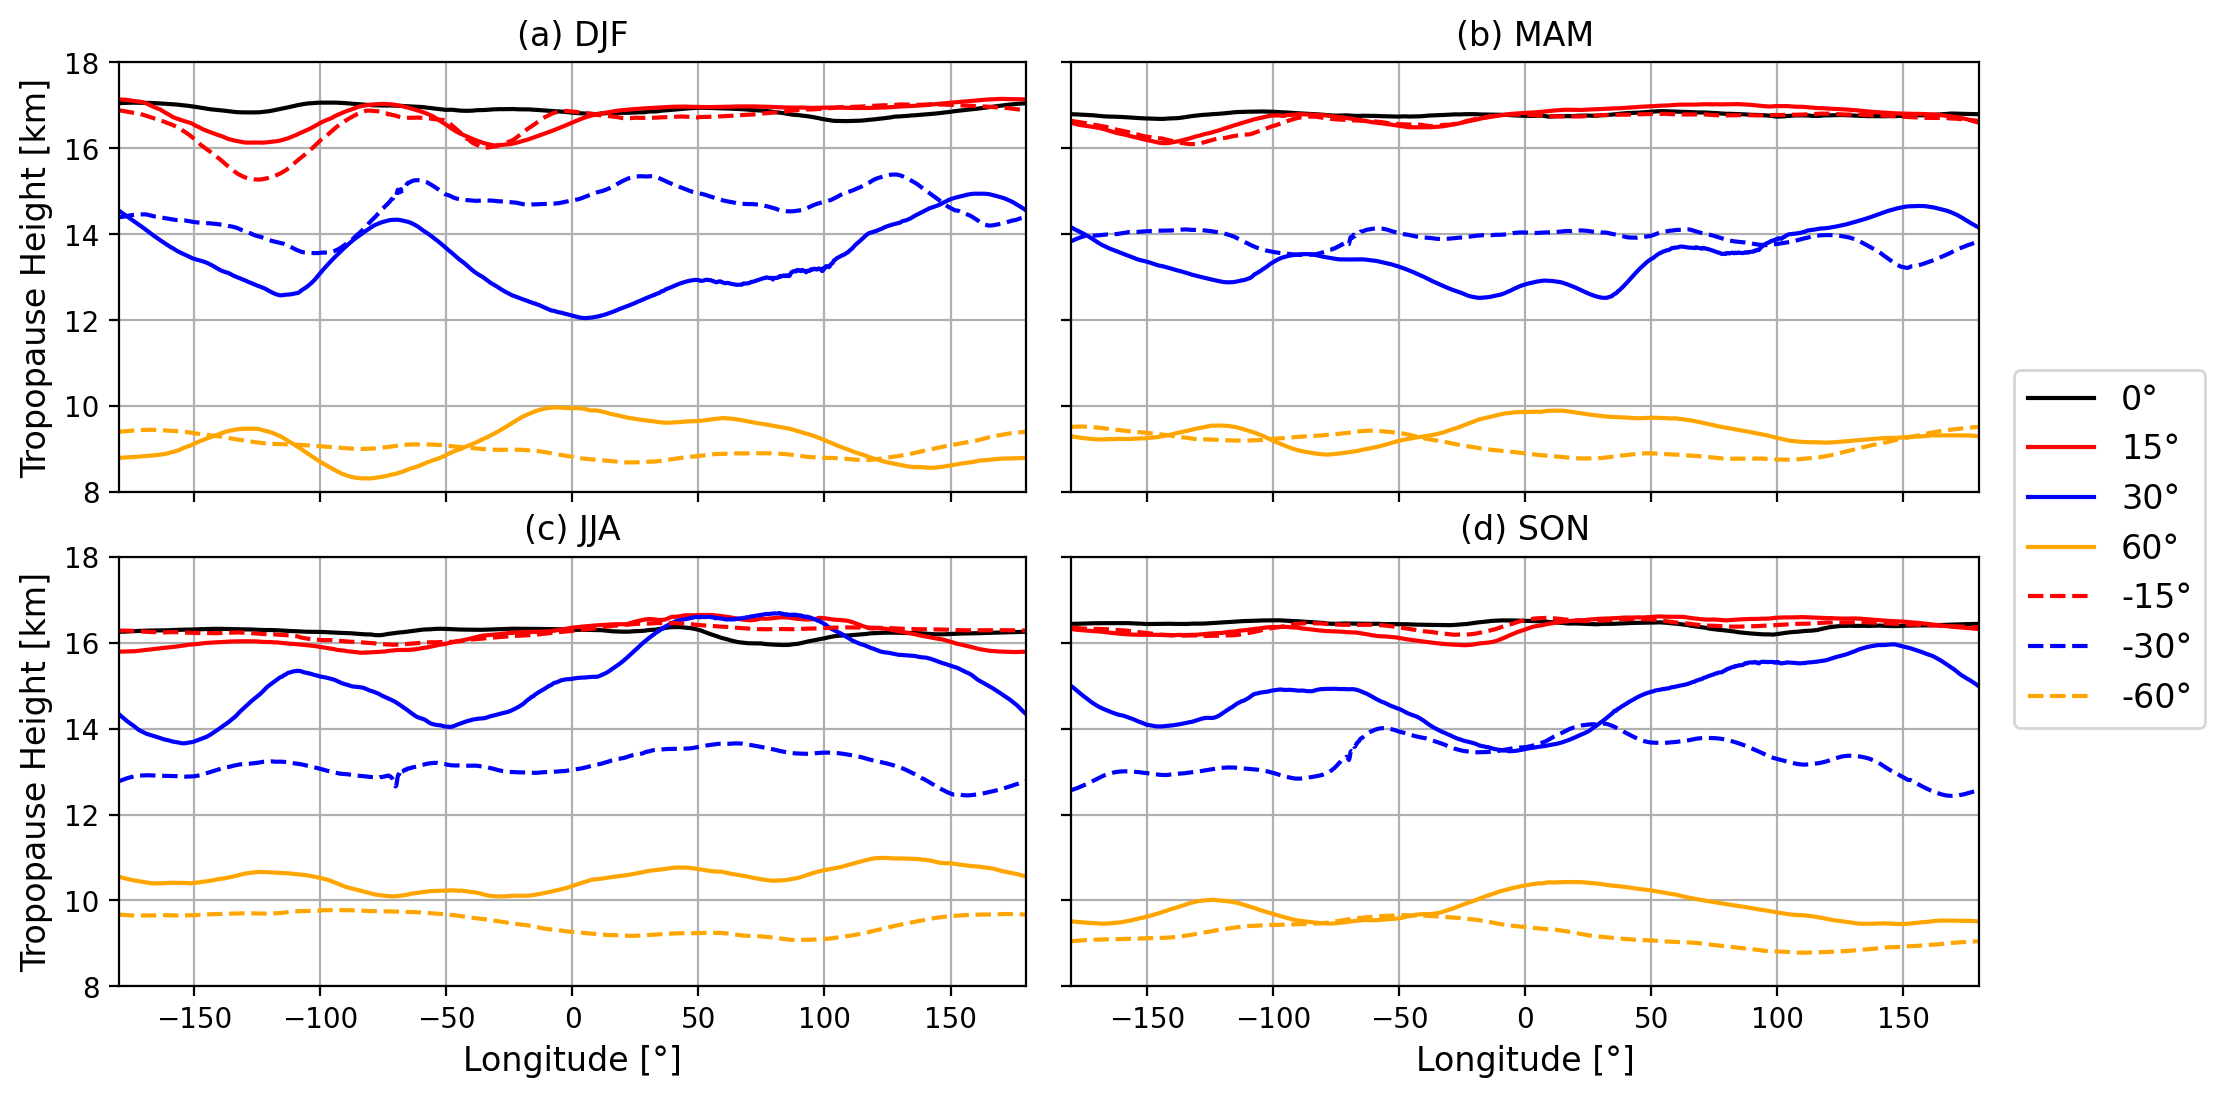

In [63]:

seasons = ["DJF", "MAM", "JJA", "SON"]
abcd = ["(a)","(b)","(c)","(d)"]

fig, axes = plt.subplots(2, 2, figsize=(12, 6), 
                        sharex=True,  # share longitude axis
                        sharey=True,   # share tropopause height axis
                        dpi=200)
axes = axes.flatten()

# Latitude ranges
lat_ranges1 = [(-2,2), (13,17), (28,32), (58,62)]
lat_ranges2 = [(-17,-13), (-32,-28), (-62,-58)]
color = ["black", "red", "blue", "orange"]


for ax, season, ii in zip(axes, seasons, abcd):
    da = seasonal_data[season]
    
    # First set of latitude bands
    for i, (lat1, lat2) in enumerate(lat_ranges1):
        da_band = da.sel(lat=slice(lat1, lat2))
        zonal_profile = da_band.mean(dim="lat")
        max_diff = float(zonal_profile.max() - zonal_profile.min())
        ax.plot(zonal_profile.lon, zonal_profile, color=color[i],
                label=f"{int((lat1+lat2)/2)}°")
    
    # Second set of latitude bands (southern)
    for i, (lat1, lat2) in enumerate(lat_ranges2, start=1):  # start=1 to match your color indexing
        da_band = da.sel(lat=slice(lat1, lat2))
        zonal_profile = da_band.mean(dim="lat")
        max_diff = float(zonal_profile.max() - zonal_profile.min())
        ax.plot(zonal_profile.lon, zonal_profile, '--', color=color[i],
                label=f"{int((lat1+lat2)/2)}°")
    
    ax.set_ylim(8, 18)
    ax.set_xlim(-180, 180)
    ax.set_title(ii+" "+season)
    ax.grid(True)

# Set axis labels only on outer panels
for ax in axes[2:]:
    ax.set_xlabel("Longitude [°]", fontsize=12)
for ax in axes[::2]:
    ax.set_ylabel("Tropopause Height [km]", fontsize=12)

# Shared legend outside
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", fontsize=12)

# plt.subplots_adjust(right=0.9, wspace=0.25, hspace=0.25)
plt.subplots_adjust(right=0.9, wspace=0.05, hspace=0.15)

plt.show()